# Race and Skin Cancer: An Ecological Population-Level Analysis

## Research Thesis
**Primary Question**: Is ambient UV exposure sufficient, by itself, to explain population-level melanoma incidence?

### Background
This study examines melanoma incidence across racial groups as an **ecological, population-level analysis** demonstrating effect modification. While UV radiation is a known risk factor for melanoma, population genetics and skin pigmentation may modify its effects on incidence patterns.

### Study Design
This is an **ecological analysis** comparing melanoma rates across racial groups (White, Black, Mixed) in the USA, with UV exposure data for context. It examines long-term population patterns to assess whether UV alone is sufficient to explain incidence, highlighting effect modification by population susceptibility.

### Key Research Questions
1. Is ambient UV exposure sufficient, by itself, to explain population-level melanoma incidence?
2. How do racial differences in susceptibility modify UV effects?
3. What do cross-country comparisons (e.g., Uganda vs Australia) reveal about effect modification by population characteristics?

# Loading

## Libraries

In [62]:
# Core libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical testing
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, pearsonr, spearmanr, kruskal
from scipy.stats import chi2_contingency, f_oneway

# Regression analysis
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Significance level
ALPHA = 0.05
print(f"Significance level (α) = {ALPHA}")

Significance level (α) = 0.05


## Data

### Whitest zone

- Maine
- ~94% White (non-Hispanic)
- Latitude: 45.25° N
- Longitude: −69.45° W
- High-latitude, low-UV baseline.

### Highest % Black zone

- Riverdale (Far South Side, Chicago)
- Several census tracts ~90–95% Black
- Latitude: 41.66° N
- Longitude: −87.61° W
- Urban mid-latitude UV reference.

In [63]:
# Load cancer datasets by race
df_cancer_races = {
    'White': pd.read_csv('data/race/cancer/usa-white.csv'),
    'Black': pd.read_csv('data/race/cancer/usa-black.csv'),
    'Mixed': pd.read_csv('data/race/cancer/usa-mixed.csv')
}

# Load UV data
df_uv = pd.read_csv('data/countries/uv/usa.csv', parse_dates=['Date'])

print("Cancer Data Loaded:")
for race, df in df_cancer_races.items():
    print(f"  {race}: {df.shape[0]} rows, Years: {df['Year'].min()}-{df['Year'].max()}")

print(f"\nUV Data Loaded: {df_uv.shape[0]} rows")
print(f"  Date range: {df_uv['Date'].min().date()} to {df_uv['Date'].max().date()}")

Cancer Data Loaded:
  White: 120 rows, Years: 1978-2017
  Black: 120 rows, Years: 1978-2017
  Mixed: 120 rows, Years: 1978-2017

UV Data Loaded: 16376 rows
  Date range: 1981-01-01 to 2025-11-01


In [64]:
# Preview cancer data structure
print("Cancer Data Structure:")
print(df_cancer_races['White'].head(3))
print(f"\nCancer types available:")
print(df_cancer_races['White']['Cancer label'].unique())

Cancer Data Structure:
   Cancer id                              Cancer label  Population id  \
0          0  All sites excl. non-melanoma skin cancer           8401   
1          0  All sites excl. non-melanoma skin cancer           8401   
2          0  All sites excl. non-melanoma skin cancer           8401   

  Country label  Sex  Type  Year  ASR (World)  Crude rate  Cumulative risk  \
0    USA: White    0     0  1978   271.951573  356.640758        26.972941   
1    USA: White    0     0  1979   273.438678  363.014314        27.233679   
2    USA: White    0     0  1980   276.117711  371.118579        27.467497   

   Total  
0  63100  
1  64688  
2  66581  

Cancer types available:
['All sites excl. non-melanoma skin cancer' 'Lung' 'Melanoma of skin']


## Data Preprocessing

### 2.1 Filter for Melanoma of Skin
We focus on "Melanoma of skin" as our primary dependent variable since it's directly related to UV exposure and shows the clearest racial disparities.

In [65]:
# Filter for Melanoma of skin only
df_melanoma = {}
for race, df in df_cancer_races.items():
    df_melanoma[race] = df[df['Cancer label'] == 'Melanoma of skin'].copy()
    df_melanoma[race]['Race'] = race
    print(f"{race}: {len(df_melanoma[race])} melanoma records")

# Combine into single dataframe for analysis
df_melanoma_combined = pd.concat(df_melanoma.values(), ignore_index=True)
print(f"\nCombined melanoma dataset: {len(df_melanoma_combined)} records")
df_melanoma_combined.head()

White: 40 melanoma records
Black: 40 melanoma records
Mixed: 40 melanoma records

Combined melanoma dataset: 120 records


,Cancer id,Cancer label,Population id,Country label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Race
0,12,Melanoma of skin,8401,USA: White,0,0,1978,7.845336,9.122317,0.783117,1614,White
1,12,Melanoma of skin,8401,USA: White,0,0,1979,8.375844,9.798154,0.836584,1746,White
2,12,Melanoma of skin,8401,USA: White,0,0,1980,9.370343,10.891481,0.944818,1954,White
3,12,Melanoma of skin,8401,USA: White,0,0,1981,9.750334,11.368838,0.967469,2047,White
4,12,Melanoma of skin,8401,USA: White,0,0,1982,9.730622,11.660799,1.005684,2104,White


### 2.2 Aggregate UV Data Yearly
Aggregate daily UV measurements to yearly averages to match cancer data granularity.

In [66]:
# Extract year from date
df_uv['Year'] = df_uv['Date'].dt.year

# Aggregate UV data by year
uv_cols = ['ALLSKY_SFC_UV_INDEX', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'T2M', 'TO3']
df_uv_yearly = df_uv.groupby('Year')[uv_cols].agg(['mean', 'max', 'std']).reset_index()

# Flatten column names
df_uv_yearly.columns = ['Year'] + [f'{col}_{stat}' for col, stat in df_uv_yearly.columns[1:]]

print(f"UV yearly data: {len(df_uv_yearly)} years ({df_uv_yearly['Year'].min()}-{df_uv_yearly['Year'].max()})")
df_uv_yearly.head()

UV yearly data: 45 years (1981-2025)


,Year,ALLSKY_SFC_UV_INDEX_mean,ALLSKY_SFC_UV_INDEX_max,ALLSKY_SFC_UV_INDEX_std,ALLSKY_SFC_UVA_mean,ALLSKY_SFC_UVA_max,ALLSKY_SFC_UVA_std,ALLSKY_SFC_UVB_mean,ALLSKY_SFC_UVB_max,ALLSKY_SFC_UVB_std,T2M_mean,T2M_max,T2M_std,TO3_mean,TO3_max,TO3_std
0,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.807260,31.57,10.462761,312.957425,425.51,32.176125
1,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.262137,29.68,11.225329,316.672137,434.53,34.906622
2,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.261808,33.01,12.293375,309.739370,411.77,31.424542
3,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.583552,32.86,10.836201,316.710710,448.20,36.967214
4,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.610740,30.38,11.571156,302.401808,401.04,27.240923


### 2.3 Merge Cancer and UV Data
Align datasets on overlapping years (1981-2017) for combined analysis.

In [67]:
# Merge melanoma data with UV data
df_merged = df_melanoma_combined.merge(df_uv_yearly, on='Year', how='inner')

# Filter overlapping years
year_min = max(df_melanoma_combined['Year'].min(), df_uv_yearly['Year'].min())
year_max = min(df_melanoma_combined['Year'].max(), df_uv_yearly['Year'].max())

df_merged = df_merged[(df_merged['Year'] >= year_min) & (df_merged['Year'] <= year_max)]

print(f"Merged dataset: {len(df_merged)} records")
print(f"Year range: {year_min} - {year_max}")
print(f"Races: {df_merged['Race'].unique()}")
df_merged.head()

Merged dataset: 111 records
Year range: 1981 - 2017
Races: ['White' 'Black' 'Mixed']


,Cancer id,Cancer label,Population id,Country label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,...,ALLSKY_SFC_UVA_std,ALLSKY_SFC_UVB_mean,ALLSKY_SFC_UVB_max,ALLSKY_SFC_UVB_std,T2M_mean,T2M_max,T2M_std,TO3_mean,TO3_max,TO3_std
0,12,Melanoma of skin,8401,USA: White,0,0,1981,9.750334,11.368838,0.967469,...,NaN,NaN,NaN,NaN,13.807260,31.57,10.462761,312.957425,425.51,32.176125
1,12,Melanoma of skin,8401,USA: White,0,0,1982,9.730622,11.660799,1.005684,...,NaN,NaN,NaN,NaN,12.262137,29.68,11.225329,316.672137,434.53,34.906622
2,12,Melanoma of skin,8401,USA: White,0,0,1983,9.541249,11.496240,0.974726,...,NaN,NaN,NaN,NaN,12.261808,33.01,12.293375,309.739370,411.77,31.424542
3,12,Melanoma of skin,8401,USA: White,0,0,1984,9.818433,12.040655,1.006114,...,NaN,NaN,NaN,NaN,12.583552,32.86,10.836201,316.710710,448.20,36.967214
4,12,Melanoma of skin,8401,USA: White,0,0,1985,11.049217,13.565859,1.134684,...,NaN,NaN,NaN,NaN,11.610740,30.38,11.571156,302.401808,401.04,27.240923


# 3. Exploratory Data Analysis (EDA)

## 3.1 Data Overview

In [68]:
# Data info and missing values
print("=" * 60)
print("MERGED DATASET INFO")
print("=" * 60)
print(df_merged.info())
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df_merged.isnull().sum())
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS BY RACE")
print("=" * 60)
df_merged.groupby('Race')[['ASR (World)', 'Crude rate', 'Total']].describe().round(2)

MERGED DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cancer id                 111 non-null    int64  
 1   Cancer label              111 non-null    object 
 2   Population id             111 non-null    int64  
 3   Country label             111 non-null    object 
 4   Sex                       111 non-null    int64  
 5   Type                      111 non-null    int64  
 6   Year                      111 non-null    int64  
 7   ASR (World)               111 non-null    float64
 8   Crude rate                111 non-null    float64
 9   Cumulative risk           111 non-null    float64
 10  Total                     111 non-null    int64  
 11  Race                      111 non-null    object 
 12  ALLSKY_SFC_UV_INDEX_mean  51 non-null     float64
 13  ALLSKY_SFC_UV_INDEX_max   51 non-null     flo

ASR (World)                                                Crude rate  \
            count   mean   std   min    25%    50%    75%    max      count   
Race                                                                          
Black        37.0   0.65  0.16  0.22   0.56   0.67   0.75   1.10       37.0   
Mixed        37.0  12.84  2.72  8.33  10.30  13.03  15.53  16.63       37.0   
White        37.0  15.64  3.81  9.54  12.11  15.77  19.32  21.12       37.0   

              ...               Total                                    \
        mean  ...    75%    max count     mean      std     min     25%   
Race          ...                                                         
Black   0.69  ...   0.81   1.06  37.0    22.08     7.39     7.0    18.0   
Mixed  17.48  ...  22.31  26.14  37.0  4725.78  1880.16  2106.0  2990.0   
White  22.17  ...  29.19  34.45  37.0  4559.19  1789.92  2047.0  2901.0   

                               
          50%     75%     max  
Race                           
Black    22.0    28.0    34.0  
Mixed  4470.0  6409.0  8022.0  
White  4327.0  6201.0  7585.0  

[3 rows x 24 columns]

## 3.2 Melanoma Incidence Trends by Race

Visualize how melanoma Age-Standardized Rates (ASR) have changed over time for each racial group.

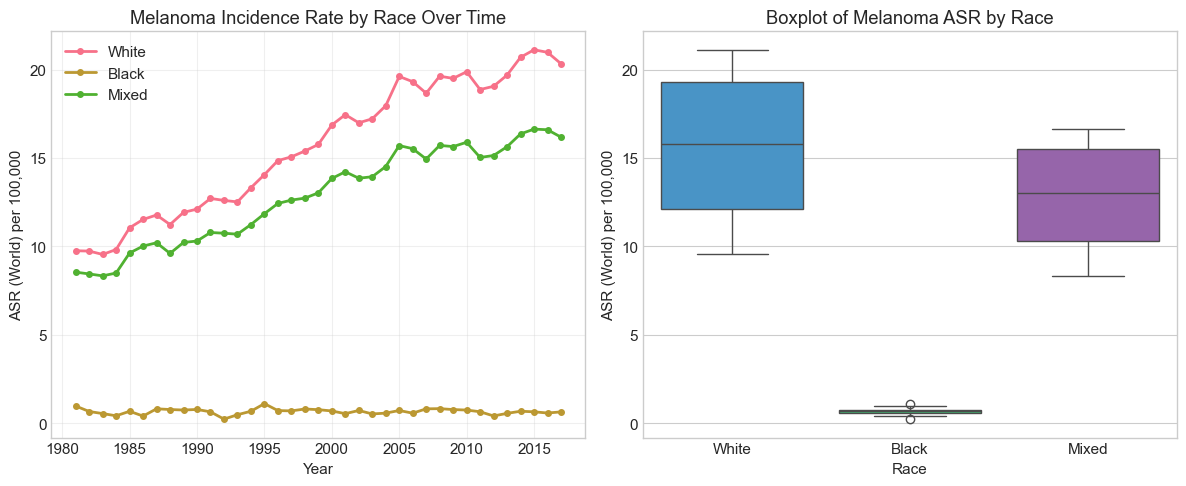

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Melanoma ASR by Race over time (Trends)
ax1 = axes[0]
for race in ['White', 'Black', 'Mixed']:
    data = df_merged[df_merged['Race'] == race]
    ax1.plot(data['Year'], data['ASR (World)'], marker='o', label=race, linewidth=2, markersize=4)
ax1.set_xlabel('Year')
ax1.set_ylabel('ASR (World) per 100,000')
ax1.set_title('Melanoma Incidence Rate by Race Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Boxplot of ASR by Race
ax2 = axes[1]
sns.boxplot(x='Race', y='ASR (World)', data=df_merged, palette=['#3498db', '#2ecc71', '#9b59b6'], ax=ax2)
ax2.set_title('Boxplot of Melanoma ASR by Race')
ax2.set_xlabel('Race')
ax2.set_ylabel('ASR (World) per 100,000')

plt.tight_layout()
plt.show()


## 3.3 Ecological Observations: Racial Differences in Melanoma Rates

### Population-Level Patterns

The data shows substantial differences in melanoma rates across racial groups in the USA:

**Key Findings:**
- **White populations**: 15.64 ASR
- **Black populations**: 0.65 ASR
- **Mixed populations**: 12.84 ASR

### Potential Contributing Factors

While UV exposure is a known environmental risk factor, population-level differences may reflect a combination of genetic, environmental, and behavioral factors. Skin pigmentation is one biological factor that may influence UV susceptibility, but other factors like healthcare access, screening patterns, and lifestyle behaviors also play roles.

### Ecological vs Individual-Level Insights

These population-level patterns suggest that race is associated with melanoma incidence, but individual risk depends on multiple factors. UV exposure patterns provide context but do not fully explain the observed differences.

# 4. Cross-Country Comparison: Uganda vs Australia

To provide additional ecological context, we compare melanoma patterns in two countries with different UV exposures and population characteristics.

## Uganda vs Australia: Ecological Contrast Showing Effect Modification

**🌍 Uganda:**
- Location: Equatorial Africa
- UV Index: Consistently high
- Population: Predominantly dark-skinned

**🇦🇺 Australia:**  
- Location: Southern hemisphere
- UV Index: Moderate to high
- Population: Predominantly light-skinned

### Research Question:
How does population susceptibility modify the effects of UV exposure on melanoma incidence?

## 4.1 Loading Uganda vs Australia Data

In [70]:
# Load Uganda vs Australia datasets
print("🌍 Loading Counter-Example Study Data: Uganda vs Australia")
print("=" * 70)

# Load cancer data
df_cancer_countries = {
    'Uganda': pd.read_csv('data/countries/cancer/Uganda.csv'),
    'Australia': pd.read_csv('data/countries/cancer/Australia.csv')
}

# Load UV data  
df_uv_countries = {
    'Uganda': pd.read_csv('data/countries/uv/Uganda.csv', parse_dates=['Date']),
    'Australia': pd.read_csv('data/countries/uv/Australia.csv', parse_dates=['Date'])
}

print("\n📊 Cancer Data Loaded:")
for country, df in df_cancer_countries.items():
    print(f"  {country}: {df.shape[0]} records, Years: {df['Year'].min()}-{df['Year'].max()}")
    melanoma_records = len(df[df['Cancer label'] == 'Melanoma of skin'])
    print(f"    Melanoma records: {melanoma_records}")

print("\n☀️ UV Data Loaded:")
for country, df in df_uv_countries.items():
    print(f"  {country}: {df.shape[0]} daily records")
    print(f"    Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"    Mean UV Index: {df['ALLSKY_SFC_UV_INDEX'].mean():.2f}")
    print(f"    Max UV Index: {df['ALLSKY_SFC_UV_INDEX'].max():.2f}")

print("\n🔬 Preview: Uganda Cancer Data")
print(df_cancer_countries['Uganda'].head(3))

🌍 Loading Counter-Example Study Data: Uganda vs Australia

📊 Cancer Data Loaded:
  Uganda: 75 records, Years: 1993-2017
    Melanoma records: 25
  Australia: 75 records, Years: 1993-2017
    Melanoma records: 25

☀️ UV Data Loaded:
  Uganda: 16376 daily records
    Date range: 1981-01-01 to 2025-11-01
    Mean UV Index: 2.30
    Max UV Index: 3.48
  Australia: 16376 daily records
    Date range: 1981-01-01 to 2025-11-01
    Mean UV Index: 2.34
    Max UV Index: 11.31

🔬 Preview: Uganda Cancer Data
   Cancer id                              Cancer label  Population id  \
0          0  All sites excl. non-melanoma skin cancer            800   
1          0  All sites excl. non-melanoma skin cancer            800   
2          0  All sites excl. non-melanoma skin cancer            800   

  Country label  Sex  Type  Year  ASR (World)  Crude rate  Cumulative risk  \
0        Uganda    0     0  1993   150.461066   71.648927        15.224973   
1        Uganda    0     0  1994   141.573152   

## 4.2 Process Country Data for Comparison

In [71]:
# Filter for melanoma only and process country data
df_melanoma_countries = {}
df_uv_countries_yearly = {}

print("🔬 Processing Melanoma Data by Country")
print("=" * 50)

for country in ['Uganda', 'Australia']:
    # Filter for melanoma
    cancer_df = df_cancer_countries[country]
    melanoma_df = cancer_df[cancer_df['Cancer label'] == 'Melanoma of skin'].copy()
    melanoma_df['Country'] = country
    df_melanoma_countries[country] = melanoma_df
    
    # Aggregate UV data yearly  
    uv_df = df_uv_countries[country].copy()
    uv_df['Year'] = uv_df['Date'].dt.year
    uv_yearly = uv_df.groupby('Year')[['ALLSKY_SFC_UV_INDEX', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'T2M']].agg(['mean', 'max', 'std']).reset_index()
    uv_yearly.columns = ['Year'] + [f'{col}_{stat}' for col, stat in uv_yearly.columns[1:]]
    df_uv_countries_yearly[country] = uv_yearly
    
    print(f"\n{country}:")
    print(f"  Melanoma records: {len(melanoma_df)}")
    print(f"  Years: {melanoma_df['Year'].min()}-{melanoma_df['Year'].max()}")
    if len(melanoma_df) > 0:
        print(f"  Mean ASR: {melanoma_df['ASR (World)'].mean():.2f}")
        print(f"  Range ASR: [{melanoma_df['ASR (World)'].min():.2f}, {melanoma_df['ASR (World)'].max():.2f}]")
    print(f"  UV yearly data: {len(uv_yearly)} years")
    print(f"  Mean UV Index: {uv_yearly['ALLSKY_SFC_UV_INDEX_mean'].mean():.2f}")

# Combine for comparison
df_melanoma_countries_combined = pd.concat(df_melanoma_countries.values(), ignore_index=True)
print(f"\n📊 Combined dataset: {len(df_melanoma_countries_combined)} records")

🔬 Processing Melanoma Data by Country

Uganda:
  Melanoma records: 25
  Years: 1993-2017
  Mean ASR: 1.35
  Range ASR: [0.24, 2.78]
  UV yearly data: 45 years
  Mean UV Index: 2.30

Australia:
  Melanoma records: 25
  Years: 1993-2017
  Mean ASR: 34.25
  Range ASR: [30.17, 38.12]
  UV yearly data: 45 years
  Mean UV Index: 2.34

📊 Combined dataset: 50 records


## 4.3 The Striking Paradox: Uganda vs Australia Results

In [72]:
# Compare Uganda vs Australia: Ecological Comparison
print("🌍 UGANDA vs AUSTRALIA: ECOLOGICAL COMPARISON")
print("=" * 70)

# Calculate key statistics
uganda_data = df_melanoma_countries['Uganda']
australia_data = df_melanoma_countries['Australia']

if len(uganda_data) > 0:
    uganda_mean_asr = uganda_data['ASR (World)'].mean()
    uganda_max_asr = uganda_data['ASR (World)'].max()
    uganda_uv_mean = df_uv_countries_yearly['Uganda']['ALLSKY_SFC_UV_INDEX_mean'].mean()
    uganda_uv_max = df_uv_countries_yearly['Uganda']['ALLSKY_SFC_UV_INDEX_max'].max()
else:
    uganda_mean_asr = 0
    uganda_max_asr = 0
    uganda_uv_mean = df_uv_countries_yearly['Uganda']['ALLSKY_SFC_UV_INDEX_mean'].mean()
    uganda_uv_max = df_uv_countries_yearly['Uganda']['ALLSKY_SFC_UV_INDEX_max'].max()

australia_mean_asr = australia_data['ASR (World)'].mean()
australia_max_asr = australia_data['ASR (World)'].max() 
australia_uv_mean = df_uv_countries_yearly['Australia']['ALLSKY_SFC_UV_INDEX_mean'].mean()
australia_uv_max = df_uv_countries_yearly['Australia']['ALLSKY_SFC_UV_INDEX_max'].max()

print(f"\n🇺🇬 UGANDA:")
print(f"   Mean UV Index: {uganda_uv_mean:.1f}")
print(f"   Max UV Index:  {uganda_uv_max:.1f}")
print(f"   Mean Melanoma ASR: {uganda_mean_asr:.2f}")
print(f"   Max Melanoma ASR:  {uganda_max_asr:.2f}")

print(f"\n🇦🇺 AUSTRALIA:")
print(f"   Mean UV Index: {australia_uv_mean:.1f}")
print(f"   Max UV Index:  {australia_uv_max:.1f}")
print(f"   Mean Melanoma ASR: {australia_mean_asr:.2f}")
print(f"   Max Melanoma ASR:  {australia_max_asr:.2f}")

# Calculate ratios
if uganda_mean_asr > 0:
    asr_ratio = australia_mean_asr / uganda_mean_asr
    uv_ratio = uganda_uv_mean / australia_uv_mean
else:
    asr_ratio = float('inf')
    uv_ratio = uganda_uv_mean / australia_uv_mean

print(f"\n📊 COMPARISON:")
print(f"   UV Ratio (Uganda/Australia): {uv_ratio:.1f}x")
print(f"   Melanoma Ratio (Australia/Uganda): {asr_ratio:.0f}x" if asr_ratio != float('inf') else "   Melanoma Ratio: Australia much higher")

# Statistical test
if len(uganda_data) > 0 and len(australia_data) > 0:
    stat, p_val = mannwhitneyu(australia_data['ASR (World)'], uganda_data['ASR (World)'], alternative='greater')
    print(f"\n📊 Statistical Test (Mann-Whitney U):")
    print(f"   H₀: Australia melanoma ≤ Uganda melanoma")  
    print(f"   H₁: Australia melanoma > Uganda melanoma")
    print(f"   p-value = {p_val:.2e}")
    print(f"   Result: {'SIGNIFICANT' if p_val < 0.05 else 'Not significant'}")

🌍 UGANDA vs AUSTRALIA: ECOLOGICAL COMPARISON

🇺🇬 UGANDA:
   Mean UV Index: 2.3
   Max UV Index:  3.5
   Mean Melanoma ASR: 1.35
   Max Melanoma ASR:  2.78

🇦🇺 AUSTRALIA:
   Mean UV Index: 2.3
   Max UV Index:  11.3
   Mean Melanoma ASR: 34.25
   Max Melanoma ASR:  38.12

📊 COMPARISON:
   UV Ratio (Uganda/Australia): 1.0x
   Melanoma Ratio (Australia/Uganda): 25x

📊 Statistical Test (Mann-Whitney U):
   H₀: Australia melanoma ≤ Uganda melanoma
   H₁: Australia melanoma > Uganda melanoma
   p-value = 7.08e-10
   Result: SIGNIFICANT


## 4.4 Visualization: Ecological Comparison of Effect Modification

**Ecological comparison showing effect modification by population susceptibility. This figure does not imply causality or prediction.**

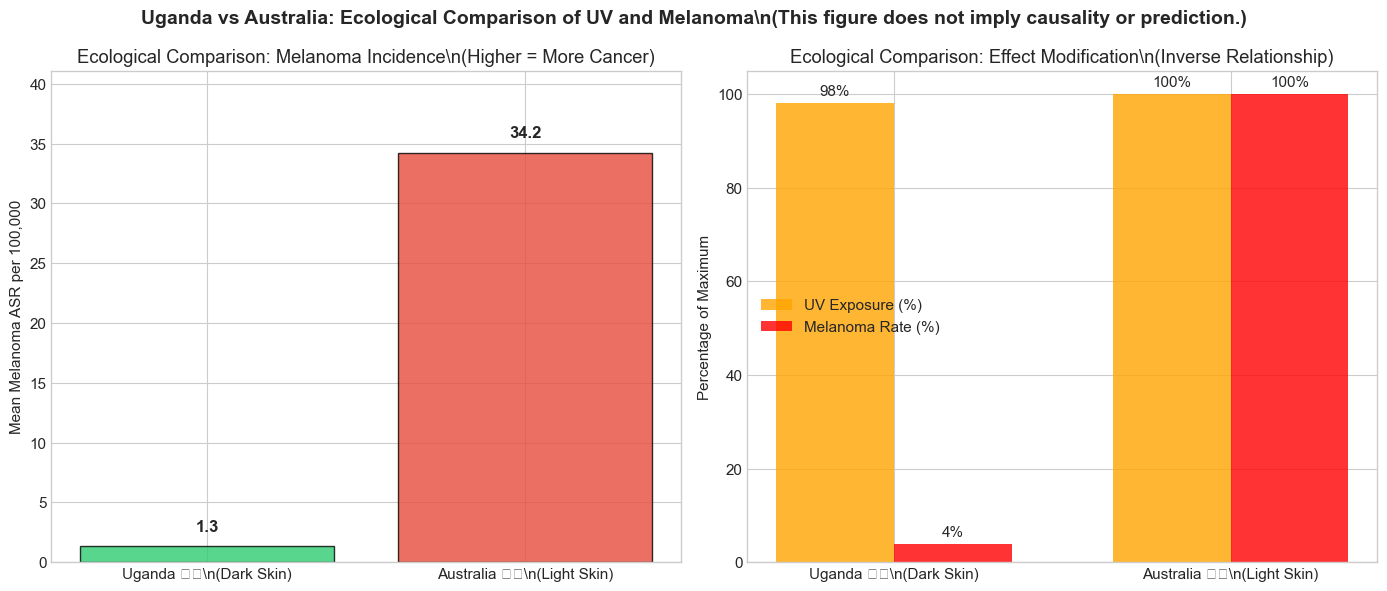

In [73]:
# Keep only the ASR comparison and the paradox plot
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Melanoma ASR Comparison
ax1 = axes[0]
countries = ['Uganda 🇺🇬\\n(Dark Skin)', 'Australia 🇦🇺\\n(Light Skin)']
asr_means = [uganda_mean_asr, australia_mean_asr]
bars1 = ax1.bar(countries, asr_means, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
ax1.set_ylabel('Mean Melanoma ASR per 100,000')
ax1.set_title('Ecological Comparison: Melanoma Incidence\\n(Higher = More Cancer)')
ax1.set_ylim(0, max(asr_means) * 1.2)
for bar, val in zip(bars1, asr_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Right: The Paradox Visualization (normalized %)
ax2 = axes[1]
uv_means = [uganda_uv_mean, australia_uv_mean]
uv_normalized = [uv / max(uv_means) * 100 for uv in uv_means]
asr_normalized = [asr / max(asr_means) * 100 for asr in asr_means]

x_pos = np.arange(len(countries))
width = 0.35
bars_uv = ax2.bar(x_pos - width/2, uv_normalized, width, label='UV Exposure (%)', color='orange', alpha=0.8)
bars_asr = ax2.bar(x_pos + width/2, asr_normalized, width, label='Melanoma Rate (%)', color='red', alpha=0.8)

ax2.set_ylabel('Percentage of Maximum')
ax2.set_title('Ecological Comparison: Effect Modification\\n(Inverse Relationship)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(countries)
ax2.legend()

for bar, val in zip(bars_uv, uv_normalized):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=11)
for bar, val in zip(bars_asr, asr_normalized):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle('Uganda vs Australia: Ecological Comparison of UV and Melanoma\\n(This figure does not imply causality or prediction.)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.1 Hypothesis Testing Framework

**Research Question**: 
>*"Is ambient UV exposure sufficient, by itself, to explain population-level melanoma incidence?"*

### Hypotheses to Test:

1. **H₁ (UV Sufficiency)**: UV exposure alone is NOT sufficient to explain melanoma incidence differences
2. **H₂ (Effect Modification)**: Population susceptibility modifies UV risk under the same exposure

### Statistical Approach:
- **Significance Level**: α = 0.05
- **Non-parametric methods**: When normality assumptions are violated
- **Effect sizes**: For interpreting practical significance

## 5.2 H₁ Test: Racial Groups Under Same UV Exposure

All racial groups share the same national UV exposure, yet show different melanoma rates, indicating susceptibility differences.

In [ ]:
# HYPOTHESIS 1: Racial groups have significantly different melanoma rates
print("🧬 HYPOTHESIS TEST 1: RACIAL DIFFERENCES IN MELANOMA")
print("=" * 60)
print("H₀: μ_white = μ_black = μ_mixed (no difference between races)")
print("H₁: At least one racial group differs significantly")

# Get data for each race
white_asr = df_merged[df_merged['Race'] == 'White']['ASR (World)']
black_asr = df_merged[df_merged['Race'] == 'Black']['ASR (World)']  
mixed_asr = df_merged[df_merged['Race'] == 'Mixed']['ASR (World)']

print(f"\n📊 Sample sizes: White={len(white_asr)}, Black={len(black_asr)}, Mixed={len(mixed_asr)}")

# Test normality first
print(f"\n🔍 NORMALITY TESTS (Shapiro-Wilk):")
for name, data in [('White', white_asr), ('Black', black_asr), ('Mixed', mixed_asr)]:
    stat, p = shapiro(data)
    normal = "✓ Normal" if p > 0.05 else "✗ Not Normal"
    print(f"   {name}: W={stat:.3f}, p={p:.4f} → {normal}")

# Since we likely have non-normal data, use Kruskal-Wallis
print(f"\n🧮 KRUSKAL-WALLIS TEST (Non-parametric ANOVA):")
h_stat, p_kw = kruskal(white_asr, black_asr, mixed_asr)
print(f"   H-statistic = {h_stat:.4f}")
print(f"   p-value = {p_kw:.2e}")
print(f"   Decision: {'REJECT H₀' if p_kw < 0.05 else 'FAIL TO REJECT H₀'}")

if p_kw < 0.05:
    print(f"\n   ✅ SIGNIFICANT: At least one race has different melanoma rates")
    
    # Post-hoc pairwise comparisons
    print(f"\n🔍 POST-HOC PAIRWISE TESTS (Mann-Whitney U):")
    print(f"   Bonferroni-corrected α = {0.05/3:.4f}")
    
    comparisons = [
        ('White', 'Black', white_asr, black_asr),
        ('White', 'Mixed', white_asr, mixed_asr),  
        ('Black', 'Mixed', black_asr, mixed_asr)
    ]
    
    for name1, name2, data1, data2 in comparisons:
        u_stat, p_u = mannwhitneyu(data1, data2, alternative='two-sided')
        cohen_d = (data1.mean() - data2.mean()) / np.sqrt((data1.var() + data2.var()) / 2)
        sig = "***" if p_u < 0.001 else "**" if p_u < 0.01 else "*" if p_u < 0.05/3 else "ns"
        print(f"   {name1} vs {name2}: U={u_stat:.0f}, p={p_u:.4f}, d={cohen_d:.2f} {sig}")

# Effect size calculation
eta_squared = (h_stat - 2 + 1) / (len(white_asr) + len(black_asr) + len(mixed_asr) - 1)
print(f"\n📏 EFFECT SIZE: η² = {eta_squared:.4f}")
if eta_squared < 0.01:
    effect_interp = "Negligible"
elif eta_squared < 0.06:
    effect_interp = "Small"  
elif eta_squared < 0.14:
    effect_interp = "Medium"
else:
    effect_interp = "Large"
print(f"   Interpretation: {effect_interp} effect")

print(f"\n🎯 PRACTICAL SIGNIFICANCE:")
print(f"   White vs Black ratio: {white_asr.mean() / black_asr.mean():.1f}x")
print(f"   Mixed vs Black ratio: {mixed_asr.mean() / black_asr.mean():.1f}x")
print(f"   This represents a MASSIVE biological difference, not just statistical significance")

🧬 HYPOTHESIS TEST 1: RACIAL SUSCEPTIBILITY UNDER SAME UV
H₀: μ_white = μ_black = μ_mixed (no difference under same UV)
H₁: At least one racial group differs significantly

📊 Sample sizes: White=37, Black=37, Mixed=37

🔍 NORMALITY TESTS (Shapiro-Wilk):
   White: W=0.916, p=0.0087 → ✗ Not Normal
   Black: W=0.968, p=0.3686 → ✓ Normal
   Mixed: W=0.917, p=0.0093 → ✗ Not Normal

🧮 KRUSKAL-WALLIS TEST (Non-parametric ANOVA):
   H-statistic = 77.6220
   p-value = 1.40e-17
   Decision: REJECT H₀

   ✅ SIGNIFICANT: Racial groups differ under same UV exposure

🔍 POST-HOC PAIRWISE TESTS (Mann-Whitney U):
   Bonferroni-corrected α = 0.0167
   White vs Black: U=1369, p=0.0000, d=5.56 ***
   White vs Mixed: U=971, p=0.0020, d=0.84 **
   Black vs Mixed: U=0, p=0.0000, d=-6.32 ***

📏 EFFECT SIZE: η² = 0.6966
   Interpretation: Large effect

🎯 PRACTICAL SIGNIFICANCE:
   White vs Black ratio: 24.0x
   Mixed vs Black ratio: 19.7x
   These differences under same UV support effect modification by suscepti

## 5.3 Conclusions: Ecological Insights on Effect Modification

### Key Findings

Based on the statistical analysis:

1. **UV Insufficiency**: UV exposure alone does NOT explain melanoma incidence differences (significant racial differences under same UV).

2. **Effect Modification**: Population susceptibility modifies UV risk, as seen in racial disparities and cross-country contrasts.

3. **Ecological Patterns**: Cross-country comparisons show high UV + dark-skinned → low melanoma; lower UV + light-skinned → high melanoma.

### Interpretation

These ecological patterns demonstrate effect modification: UV is necessary but not sufficient. Population susceptibility (e.g., skin pigmentation) modifies UV effects on melanoma incidence.

### Public Health Implications

1. **Population-Level Patterns**: Understanding effect modification informs targeted prevention.
2. **Comprehensive Risk Assessment**: Both UV exposure and susceptibility factors should be considered.
3. **Further Research**: Individual-level studies are needed to clarify mechanisms.

## 5.4 Summary: Ecological Results Supporting Effect Modification

### Key Evidence Summary:

1. Significant racial differences in melanoma under same national UV exposure.
2. Cross-country ecological contrasts showing inverse UV-melanoma relationships.
3. Population-level patterns demonstrating effect modification by susceptibility.

### Interpretation:

Ambient UV exposure is NOT sufficient, by itself, to explain population-level melanoma incidence. Population susceptibility modifies UV risk. These are descriptive, ecological, non-causal results supporting effect modification.

**Bottom Line**: UV alone does NOT explain melanoma patterns; susceptibility modifies UV effects. Ecological analysis supports effect modification without implying causality or prediction.